<a href="https://colab.research.google.com/github/Raka7317/set_project_work/blob/main/set3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ STEP 0: SETUP ================
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Environment ready

================ STEP 1: DATA LOADING ================
train.csv → shape: (160000, 2)
labels
1    80000
0    80000
Name: count, dtype: int64
test.csv → shape: (160000, 2)
labels
1    80000
0    80000
Name: count, dtype: int64
phiusiil.csv → shape: (235795, 2)
labels
1    134850
0    100945
Name: count, dtype: int64

================ STEP 2: LABEL DISTRIBUTION ================


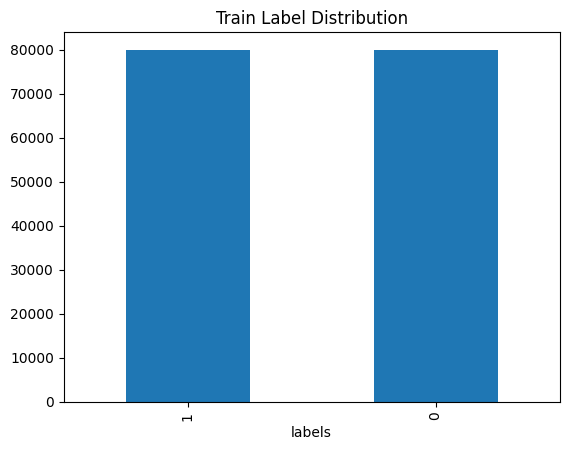

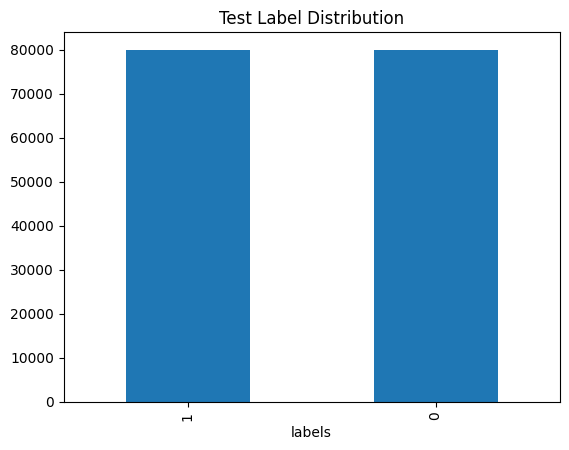

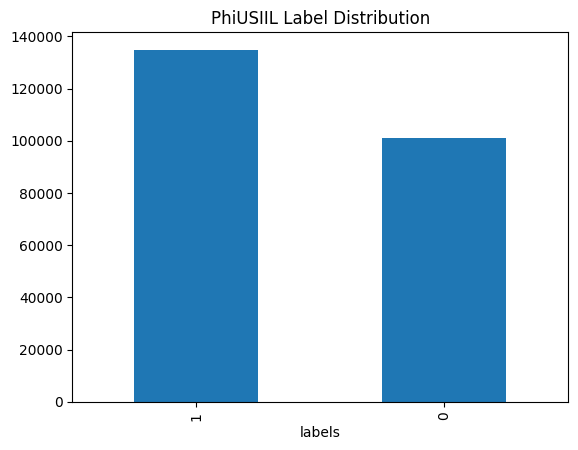


================ STEP 3: LEXICAL FEATURES ================
✔ Lexical feature dimension: 8

================ STEP 4: CHAR N-GRAM TF-IDF ================
✔ TF-IDF feature size: 1115001

================ STEP 5: FEATURE FUSION ================
✔ Fused feature dimension: 1115009

================ STEP 6: ONLINE ML (FTRL STYLE) ================
✔ Online ML trained

================ STEP 7: ANOMALY DETECTION ================


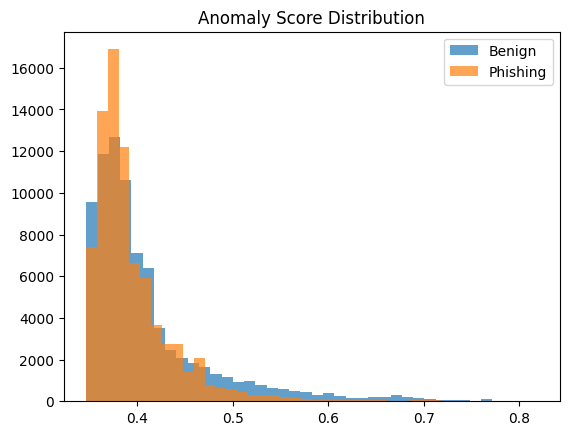


================ STEP 8: TINY TCN + ATTENTION ================
Epoch 1 Loss: 426.47994707524776
Epoch 2 Loss: 334.6586920917034
Epoch 3 Loss: 303.08836920559406


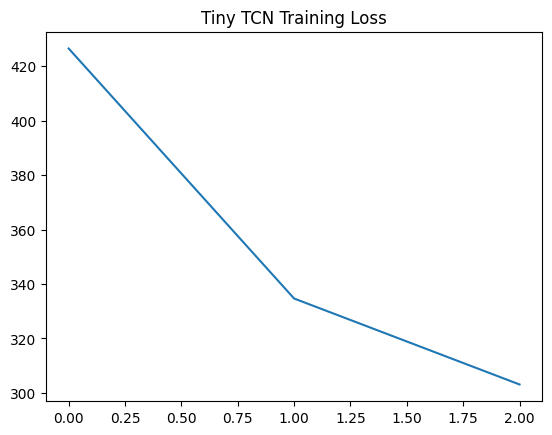


================ STEP 9: SCORE FUSION ================

================ STEP 10: EVALUATION METRICS ================

TEST SET
Accuracy : 0.87220625
Precision: 0.8047841796575125
Recall   : 0.9828125
F1-score : 0.8849333415870836
PR-AUC   : 0.9634122406468543
FPR      : 0.2384


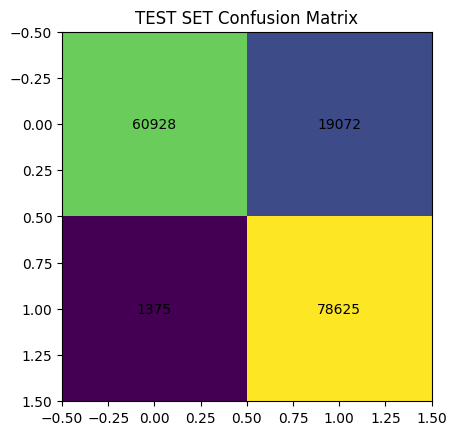


PHIUSIIL (ZERO-DAY)
Accuracy : 0.7160160308742763
Precision: 0.668196142944919
Recall   : 1.0
F1-score : 0.8011002132702829
PR-AUC   : 0.8762436846085003
FPR      : 0.6633513299321413


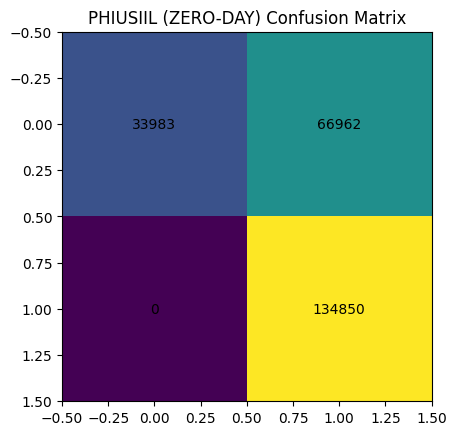


================ STEP 11: COMPUTATIONAL EFFICIENCY ================
ML inference time per URL (sec): 1.0563850402832031e-05
DL inference time per URL (sec): 0.027347087860107422
Tiny TCN parameters: 18626

================ STEP 12: CONCEPT DRIFT (PAGE–HINKLEY) ================


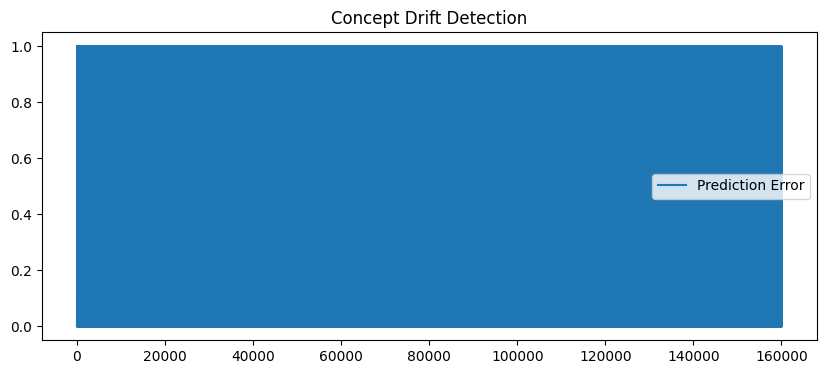


================ PIPELINE COMPLETED SUCCESSFULLY ================


In [4]:
# ==========================================================
# ONE-CELL FULL HYBRID PHISHING URL DETECTION SYSTEM
# ==========================================================

print("\n================ STEP 0: SETUP ================")

from google.colab import drive
drive.mount("/content/drive")

import os, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, confusion_matrix
)
from scipy.sparse import hstack

print("✔ Environment ready")

# ==========================================================
print("\n================ STEP 1: DATA LOADING ================")

BASE = "/content/drive/MyDrive/data"
TRAIN = os.path.join(BASE, "train.csv")
TEST  = os.path.join(BASE, "test.csv")
PHI   = os.path.join(BASE, "phiusiil.csv")

def load_data(path):
    df = pd.read_csv(path)
    if "URL" in df.columns:
        df = df.rename(columns={"URL":"url","label":"labels"})
    df = df[["url","labels"]].dropna()
    df["labels"] = df["labels"].astype(int)
    print(f"{os.path.basename(path)} → shape:", df.shape)
    print(df.labels.value_counts())
    return df

train_df = load_data(TRAIN)
test_df  = load_data(TEST)
phi_df   = load_data(PHI)

# ==========================================================
print("\n================ STEP 2: LABEL DISTRIBUTION ================")

for name, df in [("Train",train_df),("Test",test_df),("PhiUSIIL",phi_df)]:
    plt.figure()
    df.labels.value_counts().plot(kind="bar")
    plt.title(f"{name} Label Distribution")
    plt.show()

# ==========================================================
print("\n================ STEP 3: LEXICAL FEATURES ================")

def lexical_features(url):
    return [
        len(url),
        sum(c.isdigit() for c in url),
        sum(not c.isalnum() for c in url),
        url.count('.'),
        url.count('-'),
        url.count('%'),
        url.count('@'),
        math.log2(len(url)+1)
    ]

X_lex_train = np.array([lexical_features(u) for u in train_df.url])
X_lex_test  = np.array([lexical_features(u) for u in test_df.url])
X_lex_phi   = np.array([lexical_features(u) for u in phi_df.url])

print("✔ Lexical feature dimension:", X_lex_train.shape[1])

# ==========================================================
print("\n================ STEP 4: CHAR N-GRAM TF-IDF ================")

tfidf = TfidfVectorizer(analyzer="char", ngram_range=(3,5), min_df=2)
X_ng_train = tfidf.fit_transform(train_df.url)
X_ng_test  = tfidf.transform(test_df.url)
X_ng_phi   = tfidf.transform(phi_df.url)

print("✔ TF-IDF feature size:", X_ng_train.shape[1])

# ==========================================================
print("\n================ STEP 5: FEATURE FUSION ================")

X_train_ml = hstack([X_ng_train, X_lex_train]).tocsr()
X_test_ml  = hstack([X_ng_test, X_lex_test]).tocsr()
X_phi_ml   = hstack([X_ng_phi, X_lex_phi]).tocsr()

y_train, y_test, y_phi = train_df.labels, test_df.labels, phi_df.labels
print("✔ Fused feature dimension:", X_train_ml.shape[1])

# ==========================================================
print("\n================ STEP 6: ONLINE ML (FTRL STYLE) ================")

clf = SGDClassifier(loss="log_loss")
clf.fit(X_train_ml, y_train)

p_ml_test = clf.predict_proba(X_test_ml)[:,1]
p_ml_phi  = clf.predict_proba(X_phi_ml)[:,1]

print("✔ Online ML trained")

# ==========================================================
print("\n================ STEP 7: ANOMALY DETECTION ================")

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_lex_train[y_train==0])

a_test = -iso.score_samples(X_lex_test)
a_phi  = -iso.score_samples(X_lex_phi)

plt.hist(a_test[y_test==0], bins=40, alpha=0.7, label="Benign")
plt.hist(a_test[y_test==1], bins=40, alpha=0.7, label="Phishing")
plt.legend(); plt.title("Anomaly Score Distribution"); plt.show()

# ==========================================================
print("\n================ STEP 8: TINY TCN + ATTENTION ================")

MAX_LEN = 128
chars = sorted(set("".join(train_df.url)))
char2idx = {c:i+1 for i,c in enumerate(chars)}
char2idx["<PAD>"] = 0

def encode(u):
    s = [char2idx.get(c,0) for c in u[:MAX_LEN]]
    return s + [0]*(MAX_LEN-len(s))

class URLDS(Dataset):
    def __init__(self, urls, y):
        self.X=[encode(u) for u in urls]
        self.y=y.values
    def __len__(self): return len(self.y)
    def __getitem__(self,i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i],dtype=torch.float)

train_dl = DataLoader(URLDS(train_df.url,y_train),128,shuffle=True)
test_dl  = DataLoader(URLDS(test_df.url,y_test),128)
phi_dl   = DataLoader(URLDS(phi_df.url,y_phi),128)

class TinyTCNAttn(nn.Module):
    def __init__(self,v):
        super().__init__()
        self.emb=nn.Embedding(v,64,padding_idx=0)
        self.conv=nn.Conv1d(64,64,3,padding=1)
        self.attn=nn.Linear(64,1)
        self.fc=nn.Linear(64,1)
    def forward(self,x):
        x=self.emb(x).transpose(1,2)
        x=torch.relu(self.conv(x)).transpose(1,2)
        w=torch.softmax(self.attn(x).squeeze(-1),1)
        return self.fc((x*w.unsqueeze(-1)).sum(1)).squeeze()

model = TinyTCNAttn(len(char2idx))
opt = torch.optim.Adam(model.parameters(),lr=0.001)
lossf = nn.BCEWithLogitsLoss()

losses=[]
for e in range(3):
    ep=0
    for X,y in train_dl:
        opt.zero_grad()
        l=lossf(model(X),y)
        l.backward()
        opt.step()
        ep+=l.item()
    losses.append(ep)
    print(f"Epoch {e+1} Loss:",ep)

plt.plot(losses); plt.title("Tiny TCN Training Loss"); plt.show()

def dl_scores(dl):
    model.eval()
    s=[]
    with torch.no_grad():
        for X,_ in dl:
            s.extend(torch.sigmoid(model(X)).numpy())
    return np.array(s)

p_dl_test = dl_scores(test_dl)
p_dl_phi  = dl_scores(phi_dl)

# ==========================================================
print("\n================ STEP 9: SCORE FUSION ================")

α = 0.6
S_test = α*p_ml_test + (1-α)*p_dl_test*(1-a_test/np.max(a_test))
S_phi  = α*p_ml_phi  + (1-α)*p_dl_phi *(1-a_phi/np.max(a_phi))

yhat_test = (S_test>0.5).astype(int)
yhat_phi  = (S_phi>0.5).astype(int)

# ==========================================================
print("\n================ STEP 10: EVALUATION METRICS ================")

def evaluate(y, yhat, scores, name):
    acc = accuracy_score(y,yhat)
    prec = precision_score(y,yhat)
    rec = recall_score(y,yhat)
    f1 = f1_score(y,yhat)

    p,r,_ = precision_recall_curve(y,scores)
    pr_auc = auc(r,p)

    cm = confusion_matrix(y,yhat)
    TN,FP,FN,TP = cm.ravel()
    fpr = FP/(FP+TN)

    print(f"\n{name}")
    print("Accuracy :",acc)
    print("Precision:",prec)
    print("Recall   :",rec)
    print("F1-score :",f1)
    print("PR-AUC   :",pr_auc)
    print("FPR      :",fpr)

    plt.imshow(cm); plt.title(f"{name} Confusion Matrix")
    for i in range(2):
        for j in range(2):
            plt.text(j,i,cm[i,j],ha="center",va="center")
    plt.show()

evaluate(y_test,yhat_test,S_test,"TEST SET")
evaluate(y_phi,yhat_phi,S_phi,"PHIUSIIL (ZERO-DAY)")

# ==========================================================
print("\n================ STEP 11: COMPUTATIONAL EFFICIENCY ================")

start=time.time()
_ = clf.predict_proba(X_test_ml[:1000])
ml_time=(time.time()-start)/1000

sample=torch.tensor([encode(test_df.url.iloc[0])])
start=time.time()
_ = model(sample)
dl_time=time.time()-start

params=sum(p.numel() for p in model.parameters())

print("ML inference time per URL (sec):",ml_time)
print("DL inference time per URL (sec):",dl_time)
print("Tiny TCN parameters:",params)

# ==========================================================
print("\n================ STEP 12: CONCEPT DRIFT (PAGE–HINKLEY) ================")

class PageHinkley:
    def __init__(self,delta=0.005,lam=50):
        self.delta=delta; self.lam=lam; self.reset()
    def reset(self):
        self.mean=0; self.sum=0; self.min=0; self.t=0
    def update(self,x):
        self.t+=1
        self.mean += (x-self.mean)/self.t
        self.sum += x-self.mean-self.delta
        self.min=min(self.min,self.sum)
        if self.sum-self.min>self.lam:
            self.reset()
            return True
        return False

ph=PageHinkley()
loss_stream=[]
drifts=[]

for i in range(len(test_df)):
    loss=int(yhat_test[i]!=y_test.iloc[i])
    loss_stream.append(loss)
    if ph.update(loss):
        print("⚠️ Drift detected at index",i)
        drifts.append(i)

plt.figure(figsize=(10,4))
plt.plot(loss_stream,label="Prediction Error")
for d in drifts:
    plt.axvline(d,color="red",linestyle="--")
plt.legend(); plt.title("Concept Drift Detection"); plt.show()

print("\n================ PIPELINE COMPLETED SUCCESSFULLY ================")